# Phase 1: Exploratory Data Analysis (EDA) - Costa Rica Poverty Prediction
**Objective:** Explore the household dataset to identify patterns, correlations, and data quality issues before modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a clean notebook
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Load the raw dataset
df = pd.read_csv('Data/train.csv')
print(f"Dataset Loaded: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset Loaded: 9557 rows and 143 columns


In [26]:
df = pd.read_csv('Data/train.csv')

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (9557, 143)


,Id,v2a1,hacdor,rooms,hacapo,v14a,refrig,v18q,v18q1,r4h1,...,SQBescolari,SQBage,SQBhogar_total,SQBedjefe,SQBhogar_nin,SQBovercrowding,SQBdependency,SQBmeaned,agesq,Target
0,ID_279628684,190000.0,0,3,0,1,1,0,NaN,0,...,100,1849,1,100,0,1.000000,0.0,100.0,1849,4
1,ID_f29eb3ddd,135000.0,0,4,0,1,1,1,1.0,0,...,144,4489,1,144,0,1.000000,64.0,144.0,4489,4
2,ID_68de51c94,NaN,0,8,0,1,1,0,NaN,0,...,121,8464,1,0,0,0.250000,64.0,121.0,8464,4
3,ID_d671db89c,180000.0,0,5,0,1,1,1,1.0,0,...,81,289,16,121,4,1.777778,1.0,121.0,289,4
4,ID_d56d6f5f5,180000.0,0,5,0,1,1,1,1.0,0,...,121,1369,16,121,4,1.777778,1.0,121.0,1369,4


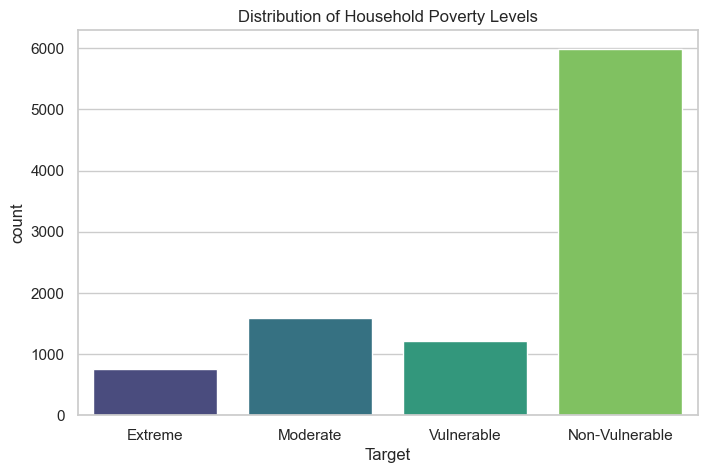

Target Percentages:
Target
4    62.739353
2    16.710265
3    12.650413
1     7.899969
Name: proportion, dtype: float64


In [3]:
# Visualize the target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Target', data=df, palette='viridis')
plt.title('Distribution of Household Poverty Levels')
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.show()

# Calculate percentages
print("Target Percentages:")
print(df['Target'].value_counts(normalize=True) * 100)

# 🏗️ cleaning Data


In [27]:
import pandas as pd
import numpy as np

# 1. Load the dataset (Ensure the path to the Data folder is correct)
df = pd.read_csv('Data/train.csv')
print("Dataset shape before cleaning:", df.shape)

# ==========================================
# Step 1: Fix Mixed-Type Columns
# ==========================================
# These columns (dependency, edjefe, edjefa) contain 'yes' and 'no' strings.
# We need to map 'yes' to 1 and 'no' to 0 so the machine learning model can process them.

mapping = {'yes': 1, 'no': 0}
mixed_cols = ['dependency', 'edjefe', 'edjefa']

for col in mixed_cols:
    df[col] = df[col].replace(mapping).astype(float)

print("Successfully converted mixed-type columns to numerical values.")

# ==========================================
# Step 2: Logical Imputation of Missing Values
# ==========================================

# 1. Column (v18q1) - Number of tablets: 
# A missing value implies the household doesn't own a tablet. Fill with 0.
df['v18q1'] = df['v18q1'].fillna(0)

# 2. Column (v2a1) - Monthly rent payment: 
# Households that don't pay rent (e.g., homeowners) have missing values here. Fill with 0.
df['v2a1'] = df['v2a1'].fillna(0)

# 3. Column (rez_esc) - Years behind in school: 
# Missing for anyone outside normal school age (under 7 or over 19). Fill with 0.
df['rez_esc'] = df['rez_esc'].fillna(0)

# 4. Columns (meaneduc) & (SQBmeaned) - Average years of education for adults:
# Only a few missing values exist (~5). Filling with 0 to prevent model errors.
df['meaneduc'] = df['meaneduc'].fillna(0)
df['SQBmeaned'] = df['SQBmeaned'].fillna(0)

# ==========================================
# Step 3: Verify Data Cleanliness and Save
# ==========================================

# Check if there are any remaining missing values in the entire dataframe
missing_left = df.isnull().sum().sum()
print(f"Total missing values left in the dataset: {missing_left}")

# Drop 'Id' column because it's a random string and useless for ML prediction
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

# Save the cleaned data to a new CSV file to preserve the original raw data
# Setting index=False prevents pandas from writing row indices as a new column
df.to_csv('Data/train_cleaned.csv', index=False)

print("Cleaned dataset successfully saved as: 'Data/train_cleaned.csv'")

Dataset shape before cleaning: (9557, 143)
Successfully converted mixed-type columns to numerical values.
Total missing values left in the dataset: 0
Cleaned dataset successfully saved as: 'Data/train_cleaned.csv'


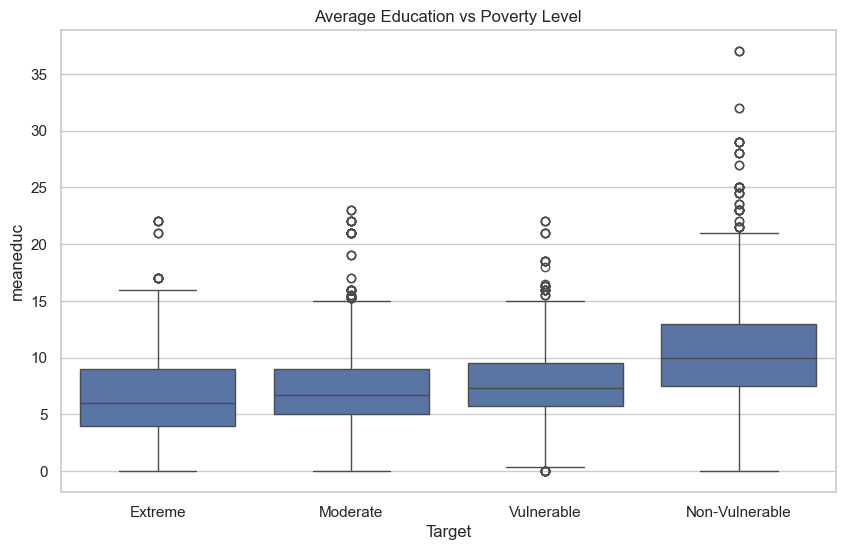

In [16]:
# Correlation between Education and Poverty
plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='meaneduc', data=df)
plt.title('Average Education vs Poverty Level')
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.show()

### 🏠 1. Housing Infrastructure vs. Poverty
This analysis examines the relationship between physical housing conditions and the household's poverty level. We focus on **`eviv3`**, which indicates whether the house has high-quality floors.

**Key Insight:** There is a severe gap in housing quality. Over 80% of Non-Vulnerable households have high-quality infrastructure, while this figure drops significantly for households in Extreme Poverty.

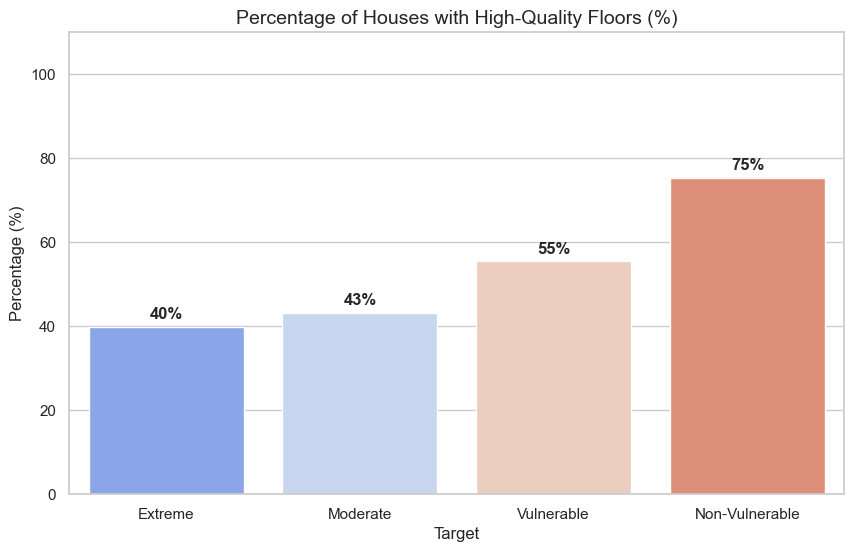

In [19]:
# Convert to percentage
housing_pct = df.groupby('Target')['eviv3'].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=housing_pct.index, y=housing_pct.values, palette='coolwarm')

# Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Percentage of Houses with High-Quality Floors (%)', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.ylabel('Percentage (%)')
plt.ylim(0, 110) # Give space for labels
plt.show()

### 👨‍👩‍👧‍👦 2. Household Overcrowding Analysis
Overcrowding is measured by the number of persons per room.

**Key Insight:** Extreme poverty households show significantly higher density, often double the ratio of stable households.

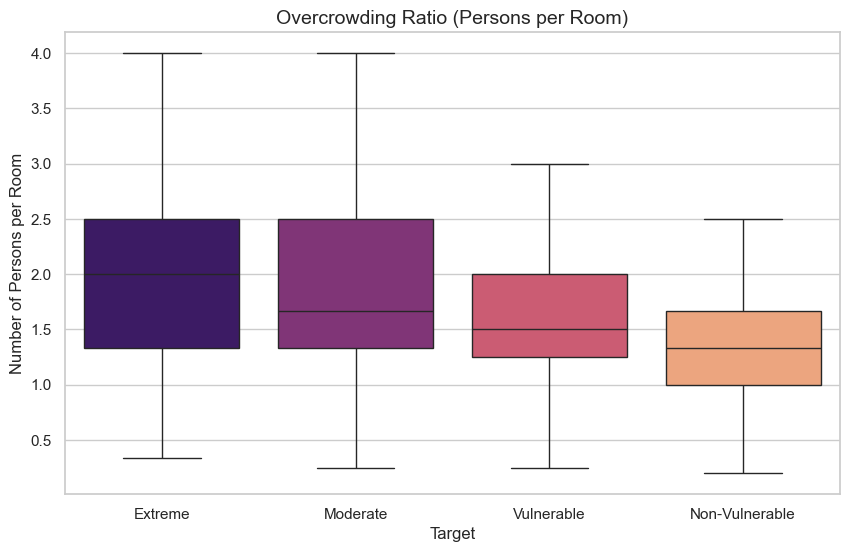

In [20]:
plt.figure(figsize=(10, 6))
# Using Boxplot to show clear integer-based medians
sns.boxplot(x='Target', y='overcrowding', data=df, palette='magma', showfliers=False)

plt.title('Overcrowding Ratio (Persons per Room)', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.ylabel('Number of Persons per Room')
plt.show()

### 🎓 3. Educational Level Analysis
Analyzing **`meaneduc`** (Average years of education for adults).

**Key Insight:** There is a clear gap; Non-Vulnerable adults have nearly double the years of schooling compared to those in Extreme Poverty.

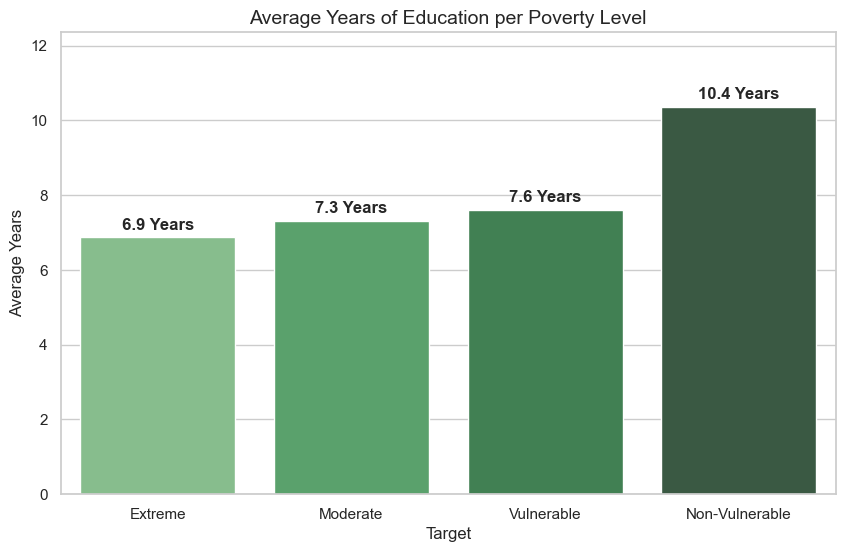

In [21]:
edu_mean = df.groupby('Target')['meaneduc'].mean()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=edu_mean.index, y=edu_mean.values, palette='Greens_d')

# Add integer/float labels on top
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f} Years', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Average Years of Education per Poverty Level', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.ylabel('Average Years')
plt.ylim(0, edu_mean.max() + 2)
plt.show()

### 📱 4. Technological Ownership (Mobile Phones)
Average quantity of mobile phones per household.

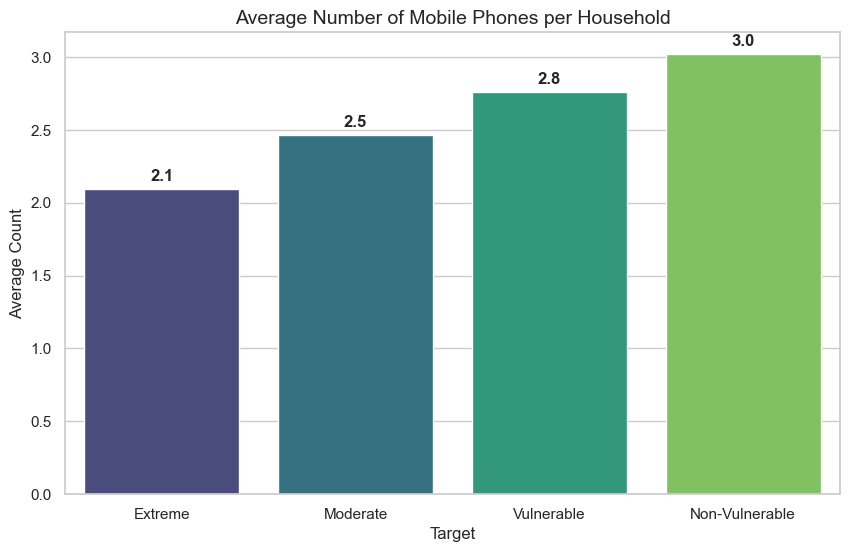

In [22]:
phone_avg = df.groupby('Target')['qmobilephone'].mean()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=phone_avg.index, y=phone_avg.values, palette='viridis')

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Average Number of Mobile Phones per Household', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.ylabel('Average Count')
plt.show()

### ⚖️ 5. The Dependency Burden
The dependency rate (`dependency`) measures the ratio of non-working members (children and elderly) to working-age adults. A higher rate indicates a heavier economic burden on the providers.

**Key Insight:** Extreme poverty is strongly linked to high dependency rates. Vulnerable households have significantly more dependents per working adult compared to stable households.

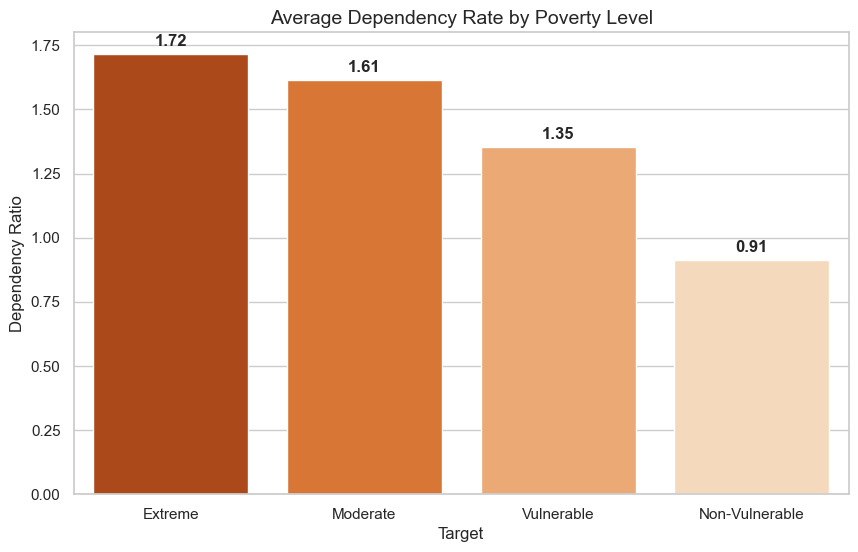

In [23]:
# Average dependency rate per poverty level
# (Assuming 'dependency' was converted to float in the cleaning step)
dep_avg = df.groupby('Target')['dependency'].mean()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=dep_avg.index, y=dep_avg.values, palette='Oranges_r')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Average Dependency Rate by Poverty Level', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.ylabel('Dependency Ratio')
plt.show()

### 💰 6. Monthly Rent Burden (`v2a1`)
Many households have missing values for monthly rent (`v2a1`). This often implies that the household fully owns their home. Here, we analyze the average rent paid by those who *do* rent.

**Key Insight:** Non-Vulnerable households pay significantly higher monthly rent, reflecting their ability to afford better housing in more expensive areas, whereas poorer families pay minimal rent (or live in precarious, rent-free setups).

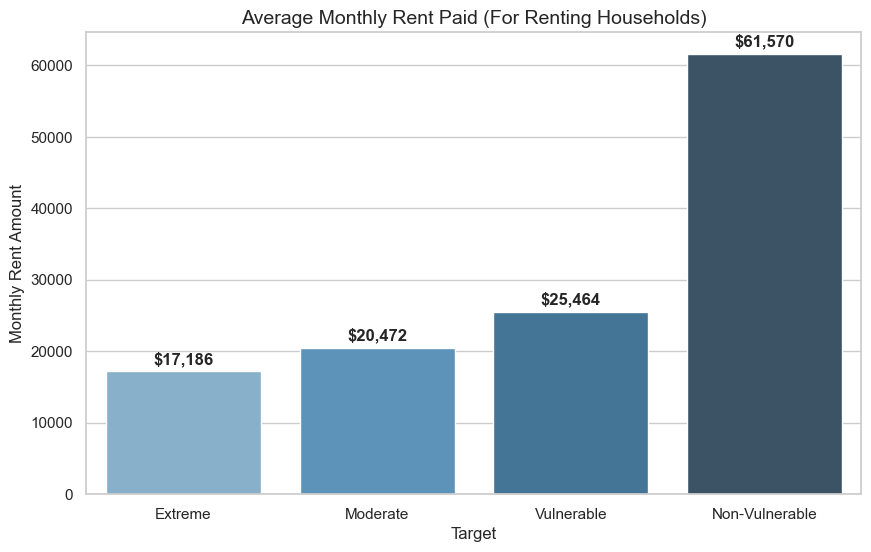

In [24]:
# Filter households that actually pay rent
rent_data = df[df['v2a1'].notnull()]
rent_avg = rent_data.groupby('Target')['v2a1'].mean()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=rent_avg.index, y=rent_avg.values, palette='Blues_d')

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Average Monthly Rent Paid (For Renting Households)', fontsize=14)
plt.xticks([0, 1, 2, 3], ['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'])
plt.ylabel('Monthly Rent Amount')
plt.show()

### 👩‍👧‍👦 7. Gender of the Household Head vs Poverty
We filter the dataset to look only at the heads of households (`parentesco1 == 1`) and analyze how the gender of the provider (`female`) impacts the poverty level.

**Key Insight:** Identifying if female-headed households represent a larger proportion within the extreme poverty brackets compared to male-headed households.

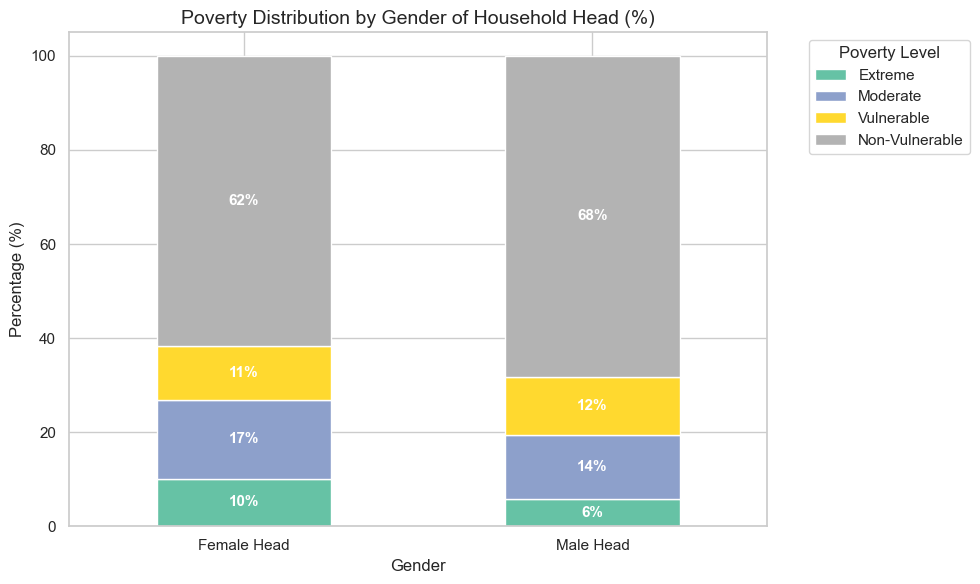

In [25]:
# Filter for Heads of Household only
heads_of_household = df[df['parentesco1'] == 1].copy()

# Map 1/0 to Female/Male for better visualization
heads_of_household['Gender'] = heads_of_household['female'].map({1: 'Female Head', 0: 'Male Head'})

# Calculate percentage of poverty levels within each gender
gender_poverty = pd.crosstab(heads_of_household['Gender'], heads_of_household['Target'], normalize='index') * 100

ax = gender_poverty.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')

# Add percentage labels inside the stacked bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only show label if the section is large enough
        ax.annotate(f'{height:.0f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Poverty Distribution by Gender of Household Head (%)', fontsize=14)
plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.legend(['Extreme', 'Moderate', 'Vulnerable', 'Non-Vulnerable'], title='Poverty Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 📝 8. Executive Summary & Key EDA Insights

After conducting a comprehensive Exploratory Data Analysis (EDA) on the Costa Rican Household dataset, we have identified several critical patterns that will directly influence our modeling strategy.

### ⚠️ The Major Challenge: Severe Class Imbalance
The most critical finding from our target distribution analysis is the **extreme class imbalance**. 
* **Non-Vulnerable (Class 4)** heavily dominates the dataset (~65-70% of the data).
* **Extreme Poverty (Class 1)** and other vulnerable classes form a small minority.
* **Action Plan:** If we train a model on this raw data, it will be heavily biased toward predicting "Non-Vulnerable". Therefore, before modeling, it is **mandatory** to handle this imbalance using techniques like **SMOTE** (Synthetic Minority Over-sampling Technique) to ensure the model learns to identify poor households accurately.

### 🔑 Top Socio-Economic Indicators (The "Why" behind Poverty):
Through our visual analysis, the following features emerged as the strongest dividers between extreme poverty and stability:
1. **The Education Shield (`meaneduc`):** Education is the most powerful weapon against poverty. There is a steep, linear drop in poverty levels as the average years of household education increase.
2. **Housing Infrastructure (`eviv3`, `epared3`):** Physical living conditions (like the quality of floors and walls) perfectly mirror the household's financial stability.
3. **The Overcrowding Effect (`overcrowding`):** Extreme poverty is highly correlated with severe overcrowding (often > 3 persons per room), indicating intense pressure on limited resources.
4. **The Dependency Burden (`dependency`):** Vulnerable families carry a much heavier load, with a higher ratio of dependents (children/elderly) relying on fewer working-age adults.

### 🚀 Next Steps (Transition to Modeling):
Based on these insights, Phase 2 will focus on:
1. Aggregating individual features to the household level.
2. Scaling features and capping outliers.
3. Grouping classes 1, 2, and 3 into a single **"Poverty"** class (Binary Classification) to improve model focus.
4. Applying **SMOTE** to the training data to conquer the class imbalance issue.
---